# EUVD Vulnerability Topic Modelling — Pipeline Rebuild

## Dual-Model BERTopic: `all-MiniLM-L6-v2` vs. SecureBERT

Fits BERTopic on the same preprocessed EUVD corpus under two embedding models. **Only** the embedding model and output artifact directory differ between runs; every other parameter is shared for direct comparability.

> **AI assistance note (UU AI Index, Level 4 — coding).**
>  The scaffolding of this notebook was generated with AI assistance (Anthropic Claude, claude-sonnet-4-6, June 2026). Under Level 4 you must: (a) keep a log of the prompts used, (b) list the tool in your appendix/resource list, and (c) cite it in the code as a comment. You remain responsible for verifying every cell and all methodological decisions. Reference: Utrecht University AI Policy, AI Index Level 4 (2024).

In [1]:
# Loading all the necessary packages

import warnings, re, json, hashlib, base64, io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ruptures as rpt

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sentence_transformers import SentenceTransformer
from sentence_transformers import models as st_models

from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# Setting a random seed for reproducibility
random_state = 42
np.random.seed(random_state)

C:\Users\menno\AppData\Local\Temp\ipykernel_11288\1915002200.py:17: DeprecationWarning:

Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.



## 1. Configuration

All of the pipeline constants for both models are featured in this step.

In [2]:
data_path      = Path("euvd_no_reject.csv")
dashboard_dir  = Path('dashboard')
dashboard_dir.mkdir(exist_ok = True)

# All relevant variables from the dataset
col_id      = "id"
col_text    = "description"
col_date    = "datePublished"
col_score   = "baseScore"
col_aliases = "aliases"
col_product = "enisaIdProduct"

date_primary_format = "%Y-%m-%d %H:%M:%S"

# Setting the parameters for the train / holdout split
split_year              = 2022
cap_per_year            = 5000
cap_per_year_holdout    = None
min_cluster_size        = 30

# Domain-specific words to remove,
# based on the exploratory data analysis
domain_stopwords = [
    "vulnerability", "vulnerabilities", "attacker", "attackers", "allow", "allows",
    "issue", "remote", "affected", "code", "user", "users", "via", "due",
    "version", "versions", "access", "file", "arbitrary"
]

# Configurations for both MiniLM and secureBERT
model_configs = [
    {
        "label":            "minilm",
        "embedding_model":  "all-MiniLM-L6-v2",
        "artifact_dir":     Path('artifacts'),
        "batch_size":       64,
        "max_seq_length":   None,
    },
    {
        "label":            "securebert",
        "embedding_model":  "ehsanaghaei/SecureBERT",
        "artifact_dir":     Path("artifacts_securebert"),
        "batch_size":       32,
        "max_seq_length":   256,
    },
]

# Setting the parameters for the dashboard and change-point detection
dashboard_top_n = 300
cpd_penalty     = 3.0

# Cut the time axis at this date to avoid showing the incomplete trailing months
# as a spurious decline. Set to None to disable.
chart_cutoff = pd.Timestamp("2026-03-31")

In [3]:
# MITRE CWE Top 25 Most Dangerous Software Weaknesses (2024), in rank order.
# Source: https://cwe.mitre.org/top25/archive/2024/2024_cwe_top25.html
# Matched against BERTopic keyword strings derived from EUVD description text.
# Earlier entries take priority — more specific patterns are listed first where CWEs overlap.
# CWE-295 and CWE-732 are supplemental entries not in the Top 25, retained for coverage.
cwe_map = [
    # ── MITRE CWE Top 25 (2024) ──────────────────────────────────────────────────
    ('CWE-79:  Cross-Site Scripting (XSS)',                    re.compile(r'(?i)xss|cross.site scripting|stored xss|reflected xss')),
    ('CWE-787: Out-of-Bounds Write',                           re.compile(r'(?i)out.of.bounds write|heap.based buffer|stack.based buffer|out of bounds write')),
    ('CWE-89:  SQL Injection',                                 re.compile(r'(?i)sql injection|sqli|sql query')),
    ('CWE-352: Cross-Site Request Forgery (CSRF)',             re.compile(r'(?i)csrf|cross.site request forgery|request forgery')),
    ('CWE-22:  Path Traversal',                                re.compile(r'(?i)path traversal|directory traversal')),
    ('CWE-125: Out-of-Bounds Read',                            re.compile(r'(?i)out.of.bounds read|oob read|over.read')),
    ('CWE-78:  OS Command Injection',                          re.compile(r'(?i)os command injection|shell injection|os command')),
    ('CWE-416: Use-After-Free',                                re.compile(r'(?i)use.after.free')),
    ('CWE-862: Missing Authorization',                         re.compile(r'(?i)missing authorization|authorization bypass|privilege escalat')),
    ('CWE-434: Unrestricted File Upload',                      re.compile(r'(?i)file upload|arbitrary upload')),
    ('CWE-94:  Code Injection',                                re.compile(r'(?i)remote code execution|arbitrary code execution|rce|code injection|template injection')),
    ('CWE-476: NULL Pointer Dereference',                      re.compile(r'(?i)null pointer|null dereference')),
    ('CWE-502: Insecure Deserialization',                      re.compile(r'(?i)deserializ')),
    ('CWE-190: Integer Overflow / Underflow',                  re.compile(r'(?i)integer overflow|integer underflow')),
    ('CWE-287: Improper Authentication',                       re.compile(r'(?i)authentication bypass|improper auth')),
    ('CWE-798: Use of Hard-coded Credentials',                 re.compile(r'(?i)hard.coded.*(password|credential|secret|key)|hardcoded.*(password|credential|secret|key)')),
    ('CWE-20:  Improper Input Validation',                     re.compile(r'(?i)improper input validation|insufficient input validation|input not validated')),
    ('CWE-77:  Command Injection',                             re.compile(r'(?i)command injection')),
    ('CWE-119: Improper Memory Operations',                    re.compile(r'(?i)memory corruption|buffer over')),
    ('CWE-306: Missing Authentication for Critical Function',  re.compile(r'(?i)missing authentication|unauthenticated access|no authentication required')),
    ('CWE-362: Race Condition',                                re.compile(r'(?i)race condition|toctou|time.of.check')),
    ('CWE-400: Denial of Service (DoS)',                       re.compile(r'(?i)denial.of.service|resource exhaustion')),
    ('CWE-611: XML External Entity (XXE)',                     re.compile(r'(?i)xxe|xml external entity')),
    ('CWE-918: Server-Side Request Forgery (SSRF)',            re.compile(r'(?i)ssrf|server.side request forgery')),
    ('CWE-200: Information Disclosure',                        re.compile(r'(?i)information disclosure|data leak|sensitive information')),
    
    # Not in the top 25, added for extra coverage
    ('CWE-295: Improper Certificate Validation',               re.compile(r'(?i)certificate valid|ssl cert|tls cert')),
    ('CWE-732: Incorrect Permission Assignment',               re.compile(r'(?i)file permission|world.writable|improper permiss')),
]

# Function which labels CWEs to corresponding topics
def classify_cwe(keywords: list) -> str:
    text = ' '.join(str(k) for k in keywords).lower()
    for label, pattern in cwe_map:
        if pattern.search(text):
            return label
    return 'CWE-Unknown: Uncategorised' # If no CWE is found

## 2. Loading the EUVD snapshot

In [4]:
df = pd.read_csv(data_path, low_memory = False)
print(f"Rows {len(df):,}    Columns: {df.shape[1]}")
print("\nColumns present:")
print(df.columns.tolist())
df.head(3)

Rows 254,247    Columns: 15

Columns present:
['id', 'description', 'datePublished', 'dateUpdated', 'baseScoreVersion', 'exploitedSince', 'baseScoreVector', 'epss', 'assigner', 'aliases', 'enisaIdVendor', 'references', 'enisaIdProduct', 'baseScore', 'enisaUuid']


,id,description,datePublished,dateUpdated,baseScoreVersion,exploitedSince,baseScoreVector,epss,assigner,aliases,enisaIdVendor,references,enisaIdProduct,baseScore,enisaUuid
0,EUVD-2026-26485,Apache Neethi is vulnerable to a Denial of Ser...,2026-05-01 08:54:41,"May 1, 2026, 8:54:41 AM",3.1,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,0.0,apache,CVE-2026-42402\n,"[{""id"": ""5bf884d0-a99a-3f6a-a801-b10eae3efbcd""...",https://lists.apache.org/thread/p826j0phhmr9f8...,"[{""id"": ""4cd8847d-33c3-3c0a-bb8e-cf75bb025f7d""...",7.5,13f156e2-987c-3c00-8794-8f9397cb981c
1,EUVD-2026-26484,@diplodoc/search-extension 1.0.0 through 3.x b...,2026-05-01 08:36:39,"May 1, 2026, 8:40:58 AM",3.1,NaN,CVSS:3.1/AV:N/AC:L/PR:L/UI:R/S:C/C:L/I:L/A:N,0.0,mitre,CVE-2026-40201\n,"[{""id"": ""b66e2332-7638-3cde-96b1-b2e605064b11""...",https://github.com/diplodoc-platform/search-ex...,"[{""id"": ""2921471c-84fd-3ac3-a069-a05978793542""...",5.4,c4a2c33d-a364-352a-8341-d40c32975b5d
2,EUVD-2026-26486,Apache Neethi does not properly detect circula...,2026-05-01 08:38:16,"May 1, 2026, 8:38:16 AM",3.1,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,0.0,apache,CVE-2026-42403\n,"[{""id"": ""9dd37fc4-cc60-3056-969f-01e1b2c38025""...",https://lists.apache.org/thread/zm6t8skkkskjwk...,"[{""id"": ""55bde1db-add9-37ab-a738-0d9faa64fe6f""...",7.5,c1ee7cac-3c9b-339a-a20b-1a2baa5d04c8


In [5]:
df.tail(3)

,id,description,datePublished,dateUpdated,baseScoreVersion,exploitedSince,baseScoreVector,epss,assigner,aliases,enisaIdVendor,references,enisaIdProduct,baseScore,enisaUuid
254244,EUVD-2020-23701,saitoha libsixel v1.8.6 was discovered to cont...,2022-03-11 00:02:34,"Mar 17, 2022, 12:02:07 AM",3.1,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,0.00,mitre,CVE-2020-36123\nGHSA-p55f-cqj7-9wjw\n,[],https://github.com/saitoha/libsixel/issues/144...,[],8.8,541806e9-5f44-3532-8dcb-5d850deea223
254245,EUVD-2022-28883,"In TightVNC 1.3.10, there is an integer signed...",2022-01-27 00:00:44,"Feb 4, 2022, 12:00:45 AM",3.1,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,0.00,mitre,GHSA-cm99-ww6p-q22x\nCVE-2022-23967\n,[],https://www.suse.com/security/cve/CVE-2022-239...,[],9.8,caecdb97-985c-326a-93b7-ca5a0c416353
254246,EUVD-2020-2485,Number assigned to issue that does not qualify...,2020-03-06 23:50:29,"Mar 6, 2020, 11:50:29 PM",NaN,NaN,NaN,0.24,zephyr,CVE-2020-10020\n,[],NaN,[],-1.0,f2f5aa23-34f5-3939-a56a-e3610518c4d5


## 3. Date parsing

Ensuring that all of the dates are in the same format.

In [6]:
def parse_dates(series, primary_format = date_primary_format):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, format = primary_format, errors = "coerce")
    missing = parsed.isna() & s.ne('') & s.ne('nan')
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(s[missing], format = "mixed", errors = "coerce")
    return parsed

df["dt"]    = parse_dates(df[col_date])
n_ok        = df["dt"].notna().sum()
n_fail      = df["dt"].isna().sum()

print(f"Parsed: {n_ok:,} ({n_ok/len(df):.2%})      Failed: {n_fail:,}")

if n_fail:
    print("\nUnparsed samples:")
    print(df.loc[df["dt"].isna(), col_date].dropna().astype(str).head(10).tolist())

Parsed: 254,247 (100.00%)      Failed: 0


In [7]:
df["year"]  = df["dt"].dt.year
df["month"] = df["dt"].dt.to_period("M")

print("Date range:", df["dt"].min(), "->", df["dt"].max())
print("Years present:", sorted(df["year"].dropna().unique().astype(int)))

Date range: 2016-05-01 00:00:00 -> 2026-05-01 08:54:41
Years present: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 4. Text cleaning

In [8]:
def minimal_clean(text):
    text = re.sub(r'\s+', ' ', str(text)).strip()
    return text

df["text_model"] = df[col_text].map(minimal_clean)
df = df[df["text_model"].str.len() > 0].reset_index(drop = True)

print(f"Modelling corpus: {len(df):,} documents")

Modelling corpus: 254,247 documents


## 5. Train / holdout split

Using a temporal split to train the dataset on years 2016 through 2022, and then adding the remaining years to the created topics.

In [9]:
def yearly_cap(frame, cap, seed = random_state):
    if cap is None:
        return frame
    return (
        frame.groupby("year", group_keys = False)
            .apply(lambda g: g.sample(min(len(g), cap), random_state = seed))
    )

train_full = df[df["year"] <= split_year].copy()
holdout    = df[df["year"] >  split_year].copy()

train   = yearly_cap(train_full, cap_per_year).reset_index(drop = True)
holdout = yearly_cap(holdout, cap_per_year_holdout).reset_index(drop = True)

print(f'Train  (<= {split_year}): {len(train_full):,} -> {len(train):,} (cap={cap_per_year})')
print(f'Holdout (> {split_year}): {len(holdout):,} (natural distribution)')
print('\nTrain rows per year:')
print(train['year'].value_counts().sort_index())

Train  (<= 2022): 116,378 -> 34,420 (cap=5000)
Holdout (> 2022): 137,869 (natural distribution)

Train rows per year:
year
2016    4420
2017    5000
2018    5000
2019    5000
2020    5000
2021    5000
2022    5000
Name: count, dtype: int64


## 6. Saving the train / holdout splits to disk

Saves the train and holdout splits to CSV immediately after they are created, before any modelling begins. This locks in the canonical row order that all downstream artifacts (embedding .npy files, assignment CSVs, and positional metadata merges in the dashboard) must stay aligned with.

In [10]:
_corpus_cols = [col_id, "text_model", "dt", "year"]

for cfg in model_configs:
    art_dir = cfg["artifact_dir"]
    art_dir.mkdir(exist_ok = True)
    train[_corpus_cols].to_csv(art_dir / "train_text.csv", index = False)
    holdout[_corpus_cols].to_csv(art_dir / "holdout_text.csv", index = False)
    lbl = cfg["label"]
    print(f"[{lbl}] train_text.csv ({len(train):,} rows),",
          f"holdout_text.csv ({len(holdout):,} rows) -> {art_dir}/")

[minilm] train_text.csv (34,420 rows), holdout_text.csv (137,869 rows) -> artifacts/
[securebert] train_text.csv (34,420 rows), holdout_text.csv (137,869 rows) -> artifacts_securebert/


## 7. BERTopic model pipeline

Following the pipeline documented by BERTopic

### 7A. ONLY RUN ONCE

**The following cells should only be run for initial training of the model. If the model has already been ran once, skip this section and continue from 7B.**

In [ ]:
# Creating a list of stopwords to remove
combined_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stopwords))
print(f"Combined stopword list: {len(combined_stopwords)} terms")

In [ ]:
# Name embedding cache files
def corpus_signature(texts, model_name):
    h = hashlib.md5()
    h.update(model_name.encode())
    h.update(str(len(texts)).encode())
    h.update(''.join(texts[:50]).encode())
    return h.hexdigest()[:8]

# Embedding model construction
def build_embedder(cfg):
    emb_name = cfg["embedding_model"]
    max_seq  = cfg["max_seq_length"]
    if max_seq is None:
        return SentenceTransformer(emb_name)
    
    # For SecureBERT, build transformer + mean-pooling modules manually
    # to enforce max_seq_length = 256 to prevent silent truncation on longerr
    # CVE descriptions
    word_model = st_models.Transformer(emb_name, max_seq_length = max_seq)
    pooling    = st_models.Pooling(
        word_model.get_word_embedding_dimension(),
        pooling_mode_mean_tokens=True,
        pooling_mode_cls_token=False,
        pooling_mode_max_tokens=False,
    )
    return SentenceTransformer(modules = [word_model, pooling])

In [ ]:
def run_model(cfg):
    label    = cfg["label"]
    emb_name = cfg["embedding_model"]
    art_dir  = cfg["artifact_dir"]
    art_dir.mkdir(exist_ok = True)
    sep = '=' * 60
    print(f"\n{sep}\n Model {label}   |   {emb_name}\n{sep}\n")

    # PART 1: Build embedding model
    embedder = build_embedder(cfg)

    # PART 2: Encode the training corpus to dense embeddings (cached)
    sig = corpus_signature(train['text_model'].tolist(), emb_name)
    cache_path = art_dir / f"train_emb_{sig}.npy"
    
    if cache_path.exists():
        train_emb = np.load(cache_path)
        print(f"[{label}] Loaded cached train embeddings: {train_emb.shape}")
    
    else:
        train_emb = embedder.encode(
            train["text_model"].tolist(), batch_size = cfg["batch_size"],
            show_progress_bar = True, convert_to_numpy = True,
        )
        np.save(cache_path, train_emb)
        print(f"[{label}] Encoded & cached: {train_emb.shape}")
    
    # PART 3: Alignment guard
    # Ensuring the embedding matrix rows correspond one-to-one with the dataframe rows
    assert len(train_emb) == len(train), (
        f"[{label}] ALIGNMENT ERROR: {len(train_emb)} embeddings vs {len(train)} rows."
        "Delete the cache and re-run."
    )

    # PART 4: Dimensionality reduction (UMAP)
    umap_model = UMAP(
        n_neighbors = 15, n_components = 5, min_dist = 0.0,
        metric = 'cosine', random_state = random_state, low_memory = True,
    )

    # PART 5: Density-based clustering (HDBSCAN)
    hdbscan_model = HDBSCAN(
        min_cluster_size = min_cluster_size, metric = "euclidean",
        cluster_selection_method = "eom", prediction_data = True,
    )

    # PART 6: Topic representation: CountVectorizer (c-TF-IDF)
    vectorizer_model = CountVectorizer(
        stop_words = combined_stopwords, ngram_range = (1, 3), min_df = 5,
    )

    # PART 7: Assemble and fitting BERTopic models
    topic_model = BERTopic(
        embedding_model = embedder, umap_model = umap_model,
        hdbscan_model = hdbscan_model, vectorizer_model = vectorizer_model,
        calculate_probabilities = False, verbose = True,
    )

    train_topics, _ = topic_model.fit_transform(train["text_model"].tolist(), train_emb)

    # PART 8: Saving the training-set topic assignments
    train_out          = train[[col_id, 'text_model', 'dt', 'year']].copy()
    train_out['topic'] = train_topics
    train_out.to_csv(art_dir / 'train_assignments.csv', index=False)

    # PART 9: Encoding holdout corpus to dense embeddings (cached)
    sig_ho        = corpus_signature(holdout['text_model'].tolist(), emb_name)
    cache_ho_path = art_dir / f'holdout_emb_{sig_ho}.npy'
    if cache_ho_path.exists():
        holdout_emb = np.load(cache_ho_path)
        print(f'[{label}] Loaded cached holdout embeddings: {holdout_emb.shape}')
    
    else:
        holdout_emb = embedder.encode(
            holdout['text_model'].tolist(), batch_size = cfg['batch_size'],
            show_progress_bar=True, convert_to_numpy=True,
        )
        np.save(cache_ho_path, holdout_emb)
        print(f'[{label}] Encoded & cached holdout: {holdout_emb.shape}')

    assert len(holdout_emb) == len(holdout), (
        f'[{label}] ALIGNMENT ERROR: {len(holdout_emb)} embeddings vs {len(holdout)} rows.'
    )

    # PART 10: Transform holdout with the fitted model
    holdout_topics, _    = topic_model.transform(holdout['text_model'].tolist(), holdout_emb)
    holdout_out          = holdout[[col_id, 'text_model', 'dt', 'year']].copy()
    holdout_out['topic'] = holdout_topics
    holdout_out.to_csv(art_dir / 'holdout_assignments.csv', index = False)

    # PART 11: Save fitted model to disk
    topic_model.save(
        str(art_dir / f"bertopic_{label}"),
        serialization = 'pickle', save_ctfidf = True, save_embedding_model = emb_name,
    )

    # PART 12: Extract topic info and log summary statistics
    info      = topic_model.get_topic_info()
    info.to_csv(art_dir / 'topic_info.csv', index=False)

    n_topics = int((info['Topic'] != -1).sum())
    n_out_tr = int((np.array(train_topics)   == -1).sum())
    n_out_ho = int((np.array(holdout_topics) == -1).sum())
    print(f'[{label}] Topics: {n_topics}')
    print(f'[{label}] Train   outlier rate: {n_out_tr / len(train_topics):.2%}')
    print(f'[{label}] Holdout outlier rate: {n_out_ho / len(holdout_topics):.2%}')

    # PART 13: Build monthly prevalance matrices
    timeline = pd.concat([
        pd.DataFrame({'month': train['month'].values,   'topic': train_topics}),
        pd.DataFrame({'month': holdout['month'].values, 'topic': holdout_topics}),
    ], ignore_index = True)
    counts = (
        timeline.groupby(['month', 'topic']).size()
                .unstack(fill_value = 0).sort_index()
    )
    shares = counts.div(counts.sum(axis = 1), axis = 0)
    counts.index = counts.index.to_timestamp()
    shares.index = shares.index.to_timestamp()
    counts.to_csv(art_dir / 'topic_counts_monthly.csv')
    shares.to_csv(art_dir / 'topic_shares_monthly.csv')
    print(f'[{label}] Artifacts saved -> {art_dir.resolve()}')

    return {
        'cfg': cfg, 'topic_model': topic_model, 'info': info,
        'train_out': train_out, 'holdout_out': holdout_out,
        'counts': counts, 'shares': shares,
    }

In [ ]:
pipeline_results = {}
for cfg in model_configs:
    pipeline_results[cfg['label']] = run_model(cfg)

print('\n--- Summary ---')
for lbl, res in pipeline_results.items():
    n_t = int((res['info']['Topic'] != -1).sum())
    print(f'  {lbl}: {n_t} topics')

### 7B. Reload from artifacts (skip training after kernel restart)

In [11]:
pipeline_results = {}

for cfg in model_configs:
    label   = cfg['label']
    art_dir = cfg['artifact_dir']

    # The pickle file contains the complete fitted model: UMAP, HDBSCAN,
    # CountVectorizer, c-TF-IDF matrix, topic embeddings — nothing is retrained.
    print(f'[{label}] Loading model from {art_dir / f"bertopic_{label}"} ...')
    topic_model = BERTopic.load(str(art_dir / f'bertopic_{label}'))
    info        = topic_model.get_topic_info()   # live from loaded model

    # Assignment CSVs (id, text_model, dt, year, topic)
    train_out   = pd.read_csv(art_dir / 'train_assignments.csv')
    holdout_out = pd.read_csv(art_dir / 'holdout_assignments.csv')

    # Monthly prevalence matrices
    # Topic-ID column names are saved as strings in CSV; restore as int.
    counts = pd.read_csv(art_dir / 'topic_counts_monthly.csv',
                         index_col = 0, parse_dates = True)
    shares = pd.read_csv(art_dir / 'topic_shares_monthly.csv',
                         index_col = 0, parse_dates = True)
    counts.columns = [int(c) for c in counts.columns]
    shares.columns = [int(c) for c in shares.columns]

    pipeline_results[label] = {
        'cfg':         cfg,
        'topic_model': topic_model,
        'info':        info,
        'train_out':   train_out,
        'holdout_out': holdout_out,
        'counts':      counts,
        'shares':      shares,
    }

    n_topics = int((info['Topic'] != -1).sum())
    n_out_tr = int((train_out['topic'] == -1).sum())
    n_out_ho = int((holdout_out['topic'] == -1).sum())
    print(f'[{label}] {n_topics} topics | '
          f'train {len(train_out):,} docs ({n_out_tr / len(train_out):.1%} outliers) | '
          f'holdout {len(holdout_out):,} docs ({n_out_ho / len(holdout_out):.1%} outliers)')

print('\npipeline_results restored. Continue to §8, §9, or §10.')

[minilm] Loading model from artifacts\bertopic_minilm ...
[minilm] 231 topics | train 34,420 docs (36.3% outliers) | holdout 137,869 docs (46.6% outliers)
[securebert] Loading model from artifacts_securebert\bertopic_securebert ...
[securebert] 193 topics | train 34,420 docs (38.3% outliers) | holdout 137,869 docs (44.5% outliers)

pipeline_results restored. Continue to §8, §9, or §10.


## 8. Reviewer dashboard (HTML)

In [12]:
# Compiled once here and reused inside extract_top_cve to avoid per-call overhead
cve_re = re.compile(r'CVE-\d{4}-\d+', re.IGNORECASE)


def extract_top_product_id(topic_id, df_combined):
    """Return the UUID of the most-referenced ENISA product for a given topic.

    `col_product` stores a JSON-encoded list of dicts, each with an 'id' key
    (a UUID string assigned by ENISA).  This function:
      1. Filters to rows belonging to `topic_id`.
      2. Parses each JSON value (skipping malformed entries silently).
      3. Counts UUID occurrences across all rows in the topic.
      4. Returns the modal UUID, or 'N/A' if no products are found.
    """
    rows = df_combined[df_combined['topic'] == topic_id]
    cnt = {}
    for val in rows[col_product].dropna():
        try:
            items = json.loads(str(val))
            if not isinstance(items, list):
                items = [items]  # normalise a bare dict to a one-element list
            for item in items:
                if isinstance(item, dict) and 'id' in item:
                    uid = str(item['id']).strip()
                    if uid:
                        cnt[uid] = cnt.get(uid, 0) + 1
        except (json.JSONDecodeError, TypeError):
            continue  # skip unparseable product fields gracefully
    return max(cnt, key=cnt.get) if cnt else 'N/A'


def make_fig_b64(topic_id, counts, shares):
    """Render a two-panel time-series figure and return it as a base64 PNG string.

    Left panel  — absolute monthly document count for the topic.
    Right panel — monthly share (fraction of all assigned docs) with PELT
                  change-point detection overlaid as vertical dashed lines.
                  PELT is skipped silently if the series has fewer than 6 points
                  or if the ruptures call raises any exception.

    Returning a base64-encoded PNG (rather than a file path) keeps the final
    HTML dashboard fully self-contained: no separate image directory is needed,
    and the file can be opened on any machine without broken image links.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Apply date cutoff to avoid showing the incomplete trailing months
    def _clip(series):
        if chart_cutoff is not None:
            return series[series.index <= chart_cutoff]
        return series

    # --- Left panel: raw count ---
    if topic_id in counts.columns:
        _clip(counts[topic_id]).plot(ax=axes[0], color='steelblue', linewidth=1.3)
    axes[0].set_title(f'Topic {topic_id} - absolute count', fontsize=10)
    axes[0].set_xlabel('Month')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # --- Right panel: share + PELT change-point detection ---
    if topic_id in shares.columns:
        s = _clip(shares[topic_id].dropna())
        s.plot(ax=axes[1], color='steelblue', linewidth=1.3)

        if len(s) >= 6:
            try:
                # PELT (Pruned Exact Linear Time) with RBF cost; `pen` controls
                # sensitivity — higher values yield fewer breakpoints.
                algo = rpt.Pelt(model='rbf', min_size=3).fit(s.values.astype(float))
                bkps = algo.predict(pen=cpd_penalty)
                # bkps[-1] is always len(s) (the signal end), so skip it
                for bp in bkps[:-1]:
                    axes[1].axvline(
                        s.index[bp], color='crimson', linestyle='--',
                        alpha=0.8, linewidth=1.2, label='Change-point',
                    )
                if bkps[:-1]:
                    axes[1].legend(fontsize=8)
            except Exception:
                pass  # silently skip CPD if ruptures fails for this topic

    axes[1].set_title(f'Topic {topic_id} - normalised count (PELT pen={cpd_penalty})', fontsize=10)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Share')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)   # release the figure to avoid memory accumulation across topics
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

In [13]:
# Workaround: storing the double-quote character in a variable avoids escaping
# issues when it is embedded inside Python f-strings that already use double
# quotes for HTML attribute values (e.g. src="data:image/png;base64,...").
q = '"'

# All CSS is inlined into the <style> block so the output HTML file is
# completely self-contained — no external stylesheets, fonts, or images are
# required.  The layout uses a fixed-width left sidebar (#nav) for topic
# navigation and a scrollable main area (#main) for the topic cards.
_CSS = (
    'body{margin:0;font-family:monospace,sans-serif;display:flex;background:#fafafa}'
    '#nav{width:190px;min-height:100vh;background:#1e1e2e;padding:14px;'
    'overflow-y:auto;flex-shrink:0;box-sizing:border-box}'
    '#nav a{display:block;color:#89b4fa;text-decoration:none;'
    'padding:3px 0;font-size:0.80em}'
    '#nav a:hover{color:#cdd6f4}'
    '#main{flex:1;padding:28px;overflow-y:auto}'
    'h1{font-size:1.15em;color:#1e1e2e;margin-top:0}'
    '.card{border:1px solid #dce1e7;border-radius:5px;'
    'margin:30px 0;padding:20px;background:#fff}'
    '.card h2{margin:0 0 12px;font-size:1em;color:#1e1e2e}'
    '.meta{border-collapse:collapse;margin-bottom:10px}'
    '.meta td{padding:3px 16px 3px 0;vertical-align:top;font-size:0.88em}'
    '.meta td:first-child{font-weight:bold;white-space:nowrap;color:#555}'
    '.plot img{max-width:100%;margin:8px 0}'
    '.doc{background:#f4f4f5;border-left:3px solid #89b4fa;'
    'padding:8px 12px;margin:5px 0;font-size:0.82em;line-height:1.55}'
)


def build_dashboard(res):
    """Build a single-file HTML reviewer dashboard for one BERTopic run.

    For each of the top `dashboard_top_n` topics (ranked by document count,
    outlier topic -1 excluded), the dashboard shows:
      - CWE classification derived from topic keywords (via `classify_cwe`)
      - Most-referenced ENISA product UUID
      - Top-10 c-TF-IDF keywords
      - A two-panel time-series chart (absolute count + share with CPD)
      - Up to three BERTopic representative descriptions

    Output is written to `dashboard/<label>/index.html` as a self-contained
    HTML file (all CSS and chart images are inlined).

    Args:
        res: One entry from `pipeline_results`, as built by `run_model` or
             the 7B reload cell.  Expected keys: cfg, topic_model, info,
             train_out, holdout_out, counts, shares.
    """
    label     = res['cfg']['label']
    emb_name  = res['cfg']['embedding_model']
    info      = res['info']
    tmodel    = res['topic_model']
    train_out = res['train_out']
    hold_out  = res['holdout_out']
    counts    = res['counts']
    shares    = res['shares']

    # Attach metadata columns by positional alignment.
    # train_out / holdout_out were saved (and reloaded) in the same row order
    # as the global `train` / `holdout` DataFrames, so a direct .values
    # assignment is safe and avoids an index-based merge that could silently
    # reorder rows.
    t_aug = train_out.copy()
    t_aug[col_product] = train[col_product].values
    h_aug = hold_out.copy()
    h_aug[col_product] = holdout[col_product].values
    # Combined frame used by the per-topic metadata helpers below
    df_comb = pd.concat([t_aug, h_aug], ignore_index=True)

    # Select the top-N meaningful topics; topic -1 is the outlier bin
    top_n = info[info['Topic'] != -1].head(dashboard_top_n)

    nav_items  = []   # sidebar anchor links, one per topic
    card_items = []   # full HTML card blocks, one per topic

    for _, row in top_n.iterrows():
        tid   = int(row['Topic'])
        count = int(row['Count'])

        # Extract the top-10 keywords for CWE classification and display
        kws  = [w for w, _ in tmodel.get_topic(tid)[:10]]
        cwe  = classify_cwe(kws)
        tprod = extract_top_product_id(tid, df_comb)

        # get_representative_docs may return None for very small topics
        try:
            rdocs = tmodel.get_representative_docs(tid) or []
        except Exception:
            rdocs = []

        # Render the time-series chart and encode it as a base64 PNG
        fig_b64 = make_fig_b64(tid, counts, shares)

        # Sidebar entry: clicking jumps to the matching card via anchor (#tN)
        nav_items.append(f'<a href=#t{tid}>Topic {tid} ({count:,})</a>')

        kw_str  = ', '.join(kws)
        # Show at most 3 representative descriptions to keep cards concise
        doc_str = ''.join(f'<div class=doc>{d}</div>' for d in rdocs[:3])

        card_parts = [
            f'<div class=card id=t{tid}>',
            f'<h2>Topic {tid} &mdash; {count:,} documents</h2>',
            '<table class=meta>',
            f'<tr><td>CWE type</td><td>{cwe}</td></tr>',
            f'<tr><td>Top product UUID</td><td>{tprod}</td></tr>',
            f'<tr><td>Keywords</td><td>{kw_str}</td></tr>',
            '</table>',
            f'<div class=plot><img src={q}data:image/png;base64,{fig_b64}{q}></div>',
            '<p><b>Representative descriptions</b></p>',
            doc_str,
            '</div>',
        ]
        card_items.append(''.join(card_parts))

    nav_str   = ''.join(nav_items)
    cards_str = ''.join(card_items)

    # Assemble the full HTML document as a list of strings, then join once
    # (more efficient than repeated string concatenation for large dashboards)
    html_parts = [
        '<!DOCTYPE html><html lang=en><head>',
        '<meta charset=utf-8>',
        f'<title>Topic Reviewer &mdash; {label}</title>',
        f'<style>{_CSS}</style>',
        '</head><body>',
        f'<div id=nav>',
        f'<b style={q}color:#cdd6f4{q}>Model: {label}</b><br><br>',
        nav_str,
        '</div>',
        '<div id=main>',
        f'<h1>Topic Reviewer Dashboard &mdash; {label}</h1>',
        f'<p style={q}color:#555{q}>Embedding: {emb_name}',
        f' &nbsp;|&nbsp; Top {len(top_n)} topics by document count</p>',
        cards_str,
        '</div></body></html>',
    ]
    html = ''.join(html_parts)

    # Write output to dashboard/<label>/index.html
    out_dir = dashboard_dir / label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / 'index.html'
    out_path.write_text(html, encoding='utf-8')
    print(f'[{label}] Dashboard -> {out_path.resolve()}')
    return out_path

In [14]:
# Build one dashboard per model and print the output path for each.
# Each call is independent — failure for one model does not abort the other.
for lbl, res in pipeline_results.items():
    build_dashboard(res)
print('Dashboard generation complete.')

[minilm] Dashboard -> C:\Users\menno\Downloads\Thesis Project\[Test] Coding\dashboard\minilm\index.html
[securebert] Dashboard -> C:\Users\menno\Downloads\Thesis Project\[Test] Coding\dashboard\securebert\index.html
Dashboard generation complete.


## 9. Topic model evaluation

Metric | What it measures | Direction
---|---|---
**c_v coherence** | Semantic coherence via sliding-window NPMI (gensim) | ↑ higher
**c_npmi coherence** | Normalised PMI over co-occurrence counts (gensim) | ↑ higher
**Topic diversity** | Fraction of unique words across all topics' top-K | ↑ higher
**Inverted RBO** | Pairwise rank-biased overlap diversity | ↑ higher
**Outlier rate** | Fraction of train docs assigned to topic −1 | context
**Silhouette** | Cluster separation in UMAP-5D space | ↑ higher
**Davies-Bouldin** | Compactness / separation ratio in UMAP-5D space | ↓ lower

In [ ]:
try:
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    HAS_GENSIM = True
    print('gensim found.')
except ImportError:
    HAS_GENSIM = False
    print('gensim not installed — c_v / c_npmi will be skipped. Run: pip install gensim')

eval_topk = 10  # words per topic used for all metrics

# Tokenise training corpus once: shared reference for coherence models
tokenized_ref = [doc.lower().split() for doc in train['text_model']]
if HAS_GENSIM:
    gensim_dict = Dictionary(tokenized_ref)
    print(f'Reference corpus: {len(tokenized_ref):,} docs, {len(gensim_dict):,} unique tokens')

In [ ]:
def _rbo_pair(l1, l2, p=0.9):
    s = 0.0
    for d in range(1, min(len(l1), len(l2)) + 1):
        overlap = len(set(l1[:d]) & set(l2[:d])) / d
        s += (p ** (d - 1)) * overlap
    return (1 - p) * s


def topic_diversity(topic_words_list, topk = eval_topk):
    all_words = [w for wl in topic_words_list for w in wl[:topk]]
    return len(set(all_words)) / len(all_words) if all_words else 0.0


def inverted_rbo(topic_words_list, p = 0.9):
    n = len(topic_words_list)
    if n < 2:
        return 0.0
    total, count = 0.0, 0
    for i in range(n):
        for j in range(i + 1, n):
            total += 1 - _rbo_pair(topic_words_list[i], topic_words_list[j], p)
            count += 1
    return total / count


def compute_c_npmi(topic_words_list, tokenized_corpus, topk = eval_topk):
    """Document-level c_npmi. Self-contained — no gensim required.

    For each topic, averages NPMI over all pairs of its top-K unigrams.
    P(w) = fraction of docs containing w; P(w_i, w_j) = fraction containing both.
    """
    import math

    # Use only unigrams (BERTopic also returns n-gram phrases)
    topic_unigrams = [
        [w for w in wl[:topk] if ' ' not in w]
        for wl in topic_words_list
    ]
    all_words = {w for wl in topic_unigrams for w in wl}
    if not all_words:
        return float('nan')

    n_docs = len(tokenized_corpus)
    df: dict = {}
    codf: dict = {}
    for doc in tokenized_corpus:
        relevant = {w for w in doc if w in all_words}
        for w in relevant:
            df[w] = df.get(w, 0) + 1
        lst = sorted(relevant)
        for i in range(len(lst)):
            for j in range(i + 1, len(lst)):
                pair = (lst[i], lst[j])
                codf[pair] = codf.get(pair, 0) + 1

    topic_scores = []
    for wl in topic_unigrams:
        if len(wl) < 2:
            continue
        pair_scores = []
        for i in range(len(wl)):
            for j in range(i + 1, len(wl)):
                wi, wj = wl[i], wl[j]
                pair   = tuple(sorted([wi, wj]))
                p_i    = df.get(wi, 0) / n_docs
                p_j    = df.get(wj, 0) / n_docs
                p_ij   = codf.get(pair, 0) / n_docs
                if p_ij > 0 and p_i > 0 and p_j > 0:
                    pmi  = math.log(p_ij / (p_i * p_j))
                    npmi = pmi / -math.log(p_ij)
                    pair_scores.append(npmi)
        if pair_scores:
            topic_scores.append(float(np.mean(pair_scores)))
    return float(np.mean(topic_scores)) if topic_scores else float('nan')


def _try_gensim_cv(topic_words_list, tokenized_corpus, gensim_dict_, topk = eval_topk):
    """Attempt gensim c_v; returns nan on any failure."""
    if not HAS_GENSIM or gensim_dict_ is None:
        return float('nan')
    # gensim dictionary contains only unigrams; filter and require >= 2 per topic
    known = set(gensim_dict_.token2id)
    tw = [[w for w in wl if w in known and ' ' not in w] for wl in topic_words_list]
    tw = [wl for wl in tw if len(wl) >= 2]
    if not tw:
        return float('nan')
    try:
        cm = CoherenceModel(
            topics = tw, texts = tokenized_corpus,
            dictionary = gensim_dict_, coherence = 'c_v',
        )
        return float(cm.get_coherence())
    except Exception as e:
        print(f'  gensim c_v failed ({e}) — returning nan')
        return float('nan')


def evaluate_model(res):
    label    = res['cfg']['label']
    emb_name = res['cfg']['embedding_model']
    art_dir  = res['cfg']['artifact_dir']
    tmodel   = res['topic_model']
    info     = res['info']
    t_out    = res['train_out']

    topic_ids   = info.loc[info['Topic'] != -1, 'Topic'].tolist()
    n_topics    = len(topic_ids)
    topic_words = [[w for w, _ in tmodel.get_topic(t)[:eval_topk]] for t in topic_ids]

    n_total   = len(t_out)
    n_outlier = int((t_out['topic'] == -1).sum())
    n_cluster = n_total - n_outlier
    sizes     = info.loc[info['Topic'] != -1, 'Count'].values

    # ---- Diversity (all topic words incl. n-grams) ----
    div  = topic_diversity(topic_words)
    irbo = inverted_rbo(topic_words)

    # ---- c_npmi (manual, always available) ----
    print(f'[{label}] Computing c_npmi ...')
    c_npmi_score = compute_c_npmi(topic_words, tokenized_ref)
    print(f'[{label}] c_npmi: {c_npmi_score:.4f}')

    # ---- c_v (gensim, best-effort) ----
    gd = gensim_dict if HAS_GENSIM else None
    print(f'[{label}] Attempting gensim c_v ...')
    c_v_score = _try_gensim_cv(topic_words, tokenized_ref, gd)
    if not np.isnan(c_v_score):
        print(f'[{label}] c_v: {c_v_score:.4f}')

    # ---- Silhouette + Davies-Bouldin in UMAP-5D ----
    sil_score  = db_score = float('nan')
    sig        = corpus_signature(train['text_model'].tolist(), emb_name)
    cache_path = art_dir / f'train_emb_{sig}.npy'
    if cache_path.exists():
        raw_emb = np.load(cache_path)
        try:
            umap_emb = tmodel.umap_model.transform(raw_emb)
            labels   = t_out['topic'].values
            mask     = labels != -1
            if mask.sum() >= 2 and len(set(labels[mask])) >= 2:
                samp      = min(5000, int(mask.sum()))
                sil_score = silhouette_score(
                    umap_emb[mask], labels[mask],
                    sample_size = samp, random_state = random_state,
                )
                db_score  = davies_bouldin_score(umap_emb[mask], labels[mask])
                print(f'[{label}] Silhouette: {sil_score:.4f}  Davies-Bouldin: {db_score:.4f}')
        except Exception as e:
            print(f'[{label}] Clustering metrics failed: {e}')
    else:
        print(f'[{label}] Embedding cache not found — skipping clustering metrics')

    def _fmt(v):
        return round(float(v), 4) if not (isinstance(v, float) and v != v) else 'N/A'

    return {
        'n_topics':            n_topics,
        'outlier_rate':        round(n_outlier / n_total, 4),
        'n_clustered':         n_cluster,
        'largest_topic_frac':  round(float(sizes.max()) / n_cluster, 4) if n_cluster > 0 else 'N/A',
        'diversity':           round(div, 4),
        'inverted_rbo':        round(irbo, 4),
        'c_npmi':              _fmt(c_npmi_score),
        'c_v':                 _fmt(c_v_score),
        'silhouette':          _fmt(sil_score),
        'davies_bouldin':      _fmt(db_score),
    }

In [ ]:
eval_results = {}
for lbl, res in pipeline_results.items():
    print(f'\nEvaluating {lbl} ...')
    eval_results[lbl] = evaluate_model(res)

# Persist per-model JSON
for lbl, res in pipeline_results.items():
    art_dir = res['cfg']['artifact_dir']
    (art_dir / 'eval_results.json').write_text(
        json.dumps(eval_results[lbl], indent = 2), encoding='utf-8'
    )

# Side-by-side comparison table
_metric_names = {
    'n_topics':           'N topics',
    'outlier_rate':       'Outlier rate (train)',
    'n_clustered':        'N clustered docs',
    'largest_topic_frac': 'Largest topic (frac. of clustered)',
    'diversity':          f'Topic diversity (top-{eval_topk})',
    'inverted_rbo':       f'Inverted RBO (top-{eval_topk})',
    'c_v':                'Coherence c_v',
    'c_npmi':             'Coherence c_npmi',
    'silhouette':         'Silhouette (UMAP-5D, sampled)',
    'davies_bouldin':     'Davies-Bouldin (UMAP-5D)',
}
rows = [
    {'Metric': name, **{lbl: eval_results[lbl].get(key, 'N/A') for lbl in eval_results}}
    for key, name in _metric_names.items()
]
eval_df = pd.DataFrame(rows)
sep = '=' * 60
print(f'\n{sep}\nEvaluation summary\n{sep}')
print(eval_df.to_string(index=False))

## 10. Cross-topic change-point emergence timeline

A single chart showing **when** each of the top topics had a structural shift in monthly share, allowing direct comparison across topics. Topics are sorted top-to-bottom by their earliest detected change-point, so the chart reads as a rough emergence order from earliest (top) to latest (bottom).

In [ ]:
from matplotlib.lines import Line2D


def build_emergence_timeline(res, top_n=None, min_series_len=6):
    """Build a cross-topic emergence timeline showing PELT change-point months.

    For each of the top `top_n` topics (by document count, topic −1 excluded),
    runs PELT on the monthly share series using the global `cpd_penalty` and
    collects every detected change-point month.  Topics are then sorted by their
    first change-point date (earliest at top); topics with no change-point are
    placed at the bottom in document-count order.

    Layout
    ------
    Y-axis  : one row per topic, labelled "T<id>: kw1, kw2, kw3"
    X-axis  : calendar months (shared across all topics)
    Diamond : first change-point  (the "emergence" signal)
    Circle  : subsequent change-points
    Grey ×  : topic with no change-point detected

    Output
    ------
    Saves  dashboard/<label>/topic_emergence_timeline.png
    Returns (matplotlib Figure, DataFrame with columns
             [topic_id, label, cwe, count, first_cp, all_cps])
    """
    label  = res['cfg']['label']
    info   = res['info']
    tmodel = res['topic_model']
    shares = res['shares']

    if top_n is None:
        top_n = dashboard_top_n

    top_topics = info[info['Topic'] != -1].head(top_n)

    rows = []
    for _, row in top_topics.iterrows():
        tid = int(row['Topic'])
        if tid not in shares.columns:
            continue
        s = shares[tid].dropna()
        # Apply cutoff before CPD so detected change-points stay within the visible range
        if CHART_CUTOFF is not None:
            s = s[s.index <= CHART_CUTOFF]
        if len(s) < min_series_len:
            continue

        kws         = [w for w, _ in tmodel.get_topic(tid)[:5]]
        cwe         = classify_cwe(kws)
        short_label = f"T{tid}: {', '.join(kws[:3])}"

        cps = []
        try:
            algo = rpt.Pelt(model='rbf', min_size=3).fit(s.values.astype(float))
            bkps = algo.predict(pen=cpd_penalty)
            cps  = [s.index[bp] for bp in bkps[:-1]]   # bkps[-1] == len(s), skip it
        except Exception:
            pass

        rows.append({
            'topic_id':  tid,
            'label':     short_label,
            'cwe':       cwe,
            'count':     int(row['Count']),
            'all_cps':   cps,
            'first_cp':  cps[0] if cps else pd.NaT,
        })

    df_cp = pd.DataFrame(rows)

    # Sort: topics with a change-point by date (earliest first),
    # then topics without a change-point in document-count order.
    has_cp  = df_cp[df_cp['first_cp'].notna()].sort_values('first_cp').reset_index(drop=True)
    no_cp   = df_cp[df_cp['first_cp'].isna()].sort_values('count', ascending=False).reset_index(drop=True)
    df_cp   = pd.concat([has_cp, no_cp], ignore_index=True)

    # ── Colour map: one colour per unique CWE category ────────────────────────
    cwe_cats  = df_cp['cwe'].unique()
    cmap      = plt.cm.get_cmap('tab20', max(len(cwe_cats), 1))
    cwe_color = {cat: cmap(i) for i, cat in enumerate(cwe_cats)}

    # ── Figure ────────────────────────────────────────────────────────────────
    n_rows  = len(df_cp)
    fig_h   = max(6, n_rows * 0.40)
    fig, ax = plt.subplots(figsize=(15, fig_h))

    x_min = shares.index.min()
    x_max = CHART_CUTOFF if CHART_CUTOFF is not None else shares.index.max()

    for y_pos, (_, r) in enumerate(df_cp.iterrows()):
        color = cwe_color[r['cwe']]

        # Faint horizontal guide-line spanning the full time range
        ax.plot([x_min, x_max], [y_pos, y_pos],
                color='#e4e4e4', linewidth=0.9, zorder=1)

        cps = r['all_cps']
        if cps:
            for i, cp in enumerate(cps):
                if i == 0:
                    # First change-point: large filled diamond
                    ax.scatter(cp, y_pos, s=110, color=color,
                               marker='D', zorder=4,
                               edgecolors='white', linewidths=0.7)
                else:
                    # Subsequent change-points: smaller open circle
                    ax.scatter(cp, y_pos, s=50, color=color,
                               marker='o', zorder=3,
                               edgecolors=color, facecolors='none', linewidths=1.2)
        else:
            # No change-point: small grey cross at the series midpoint
            mid = shares.index[len(shares) // 2]
            ax.scatter(mid, y_pos, s=45, color='#aaaaaa',
                       marker='x', zorder=2, linewidths=1.1)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(df_cp['label'].tolist(), fontsize=7.5)
    ax.invert_yaxis()   # rank-1 topic (earliest emergence) at the top
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_title(
        f'Topic emergence timeline — {label}\n'
        f'◆ first change-point (emergence)  ○ subsequent change-points  '
        f'× no change-point detected   (PELT RBF, pen={cpd_penalty})',
        fontsize=9.5,
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Legend: one swatch per CWE category ──────────────────────────────────
    legend_handles = [
        Line2D([0], [0], marker='D', color='w',
               markerfacecolor=cwe_color[c], markersize=7,
               label=c[:45])
        for c in cwe_cats
    ]
    ax.legend(
        handles=legend_handles,
        loc='lower right',
        fontsize=6.5,
        framealpha=0.88,
        title='CWE category',
        title_fontsize=7,
    )

    plt.tight_layout()

    out_dir  = dashboard_dir / label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / 'topic_emergence_timeline.png'
    fig.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'[{label}] Emergence timeline -> {out_path.resolve()}')

    return fig, df_cp


Emergence timeline: minilm


C:\Users\menno\AppData\Local\Temp\ipykernel_35960\4260559585.py:77: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



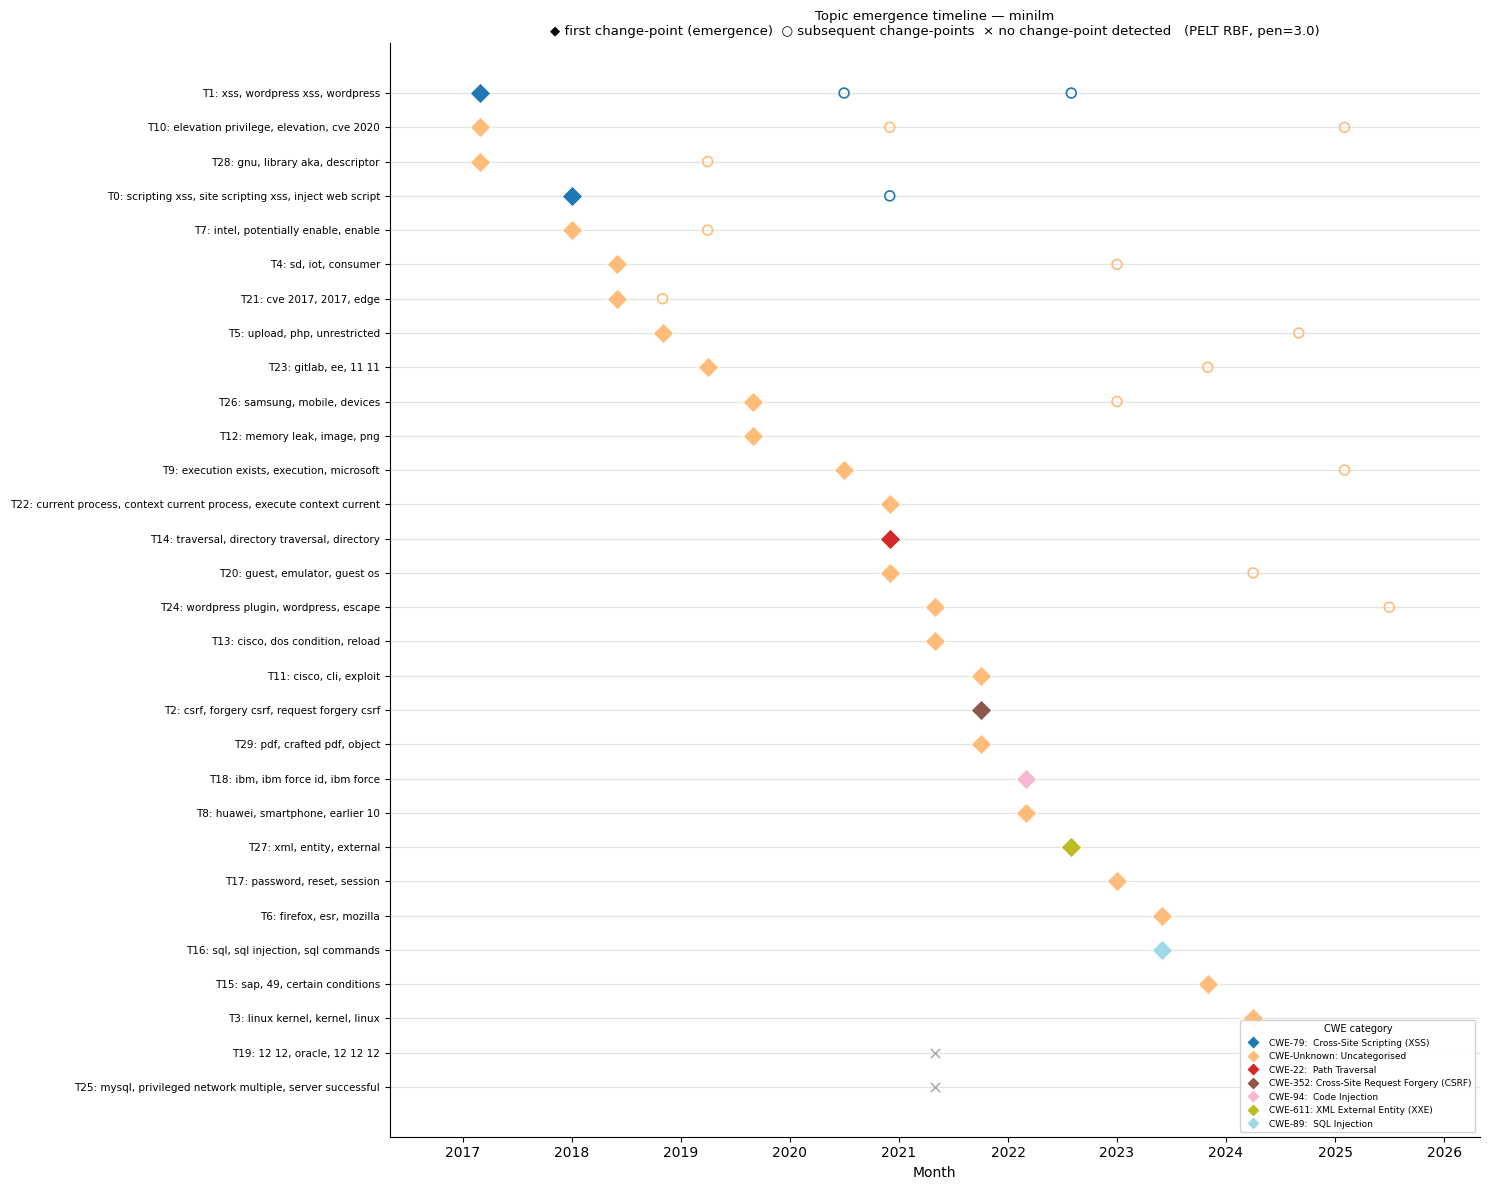

[minilm] Emergence timeline -> C:\Users\menno\Downloads\Thesis Project\[Test] Coding\dashboard\minilm\topic_emergence_timeline.png

28/30 topics have at least one detected change-point.

                                                           Topic label                                        CWE First change-point  Doc count
                                     T1: xss, wordpress xss, wordpress        CWE-79:  Cross-Site Scripting (XSS)            2017-03        604
                         T10: elevation privilege, elevation, cve 2020                 CWE-Unknown: Uncategorised            2017-03        258
                                     T28: gnu, library aka, descriptor                 CWE-Unknown: Uncategorised            2017-03        180
              T0: scripting xss, site scripting xss, inject web script        CWE-79:  Cross-Site Scripting (XSS)            2018-01        607
                                 T7: intel, potentially enable, enable                 CWE-Un

C:\Users\menno\AppData\Local\Temp\ipykernel_35960\4260559585.py:77: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



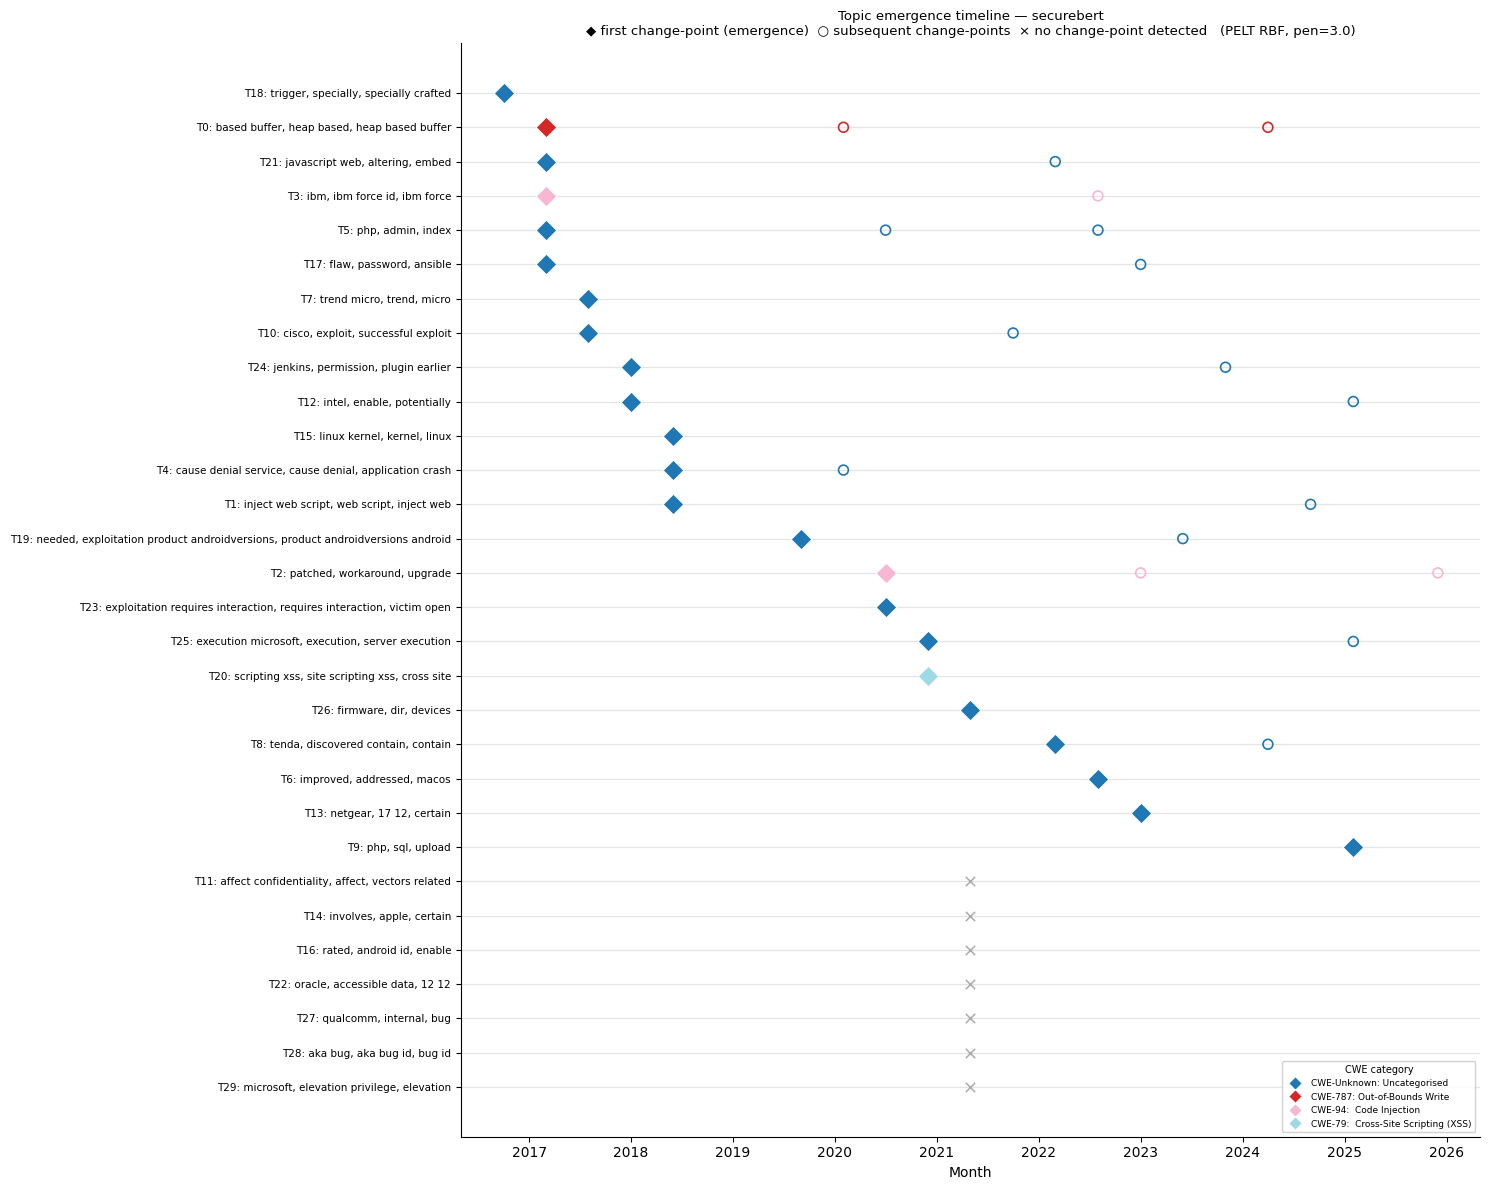

[securebert] Emergence timeline -> C:\Users\menno\Downloads\Thesis Project\[Test] Coding\dashboard\securebert\topic_emergence_timeline.png

23/30 topics have at least one detected change-point.

                                                                       Topic label                                 CWE First change-point  Doc count
                                        T18: trigger, specially, specially crafted          CWE-Unknown: Uncategorised            2016-10        211
                                   T0: based buffer, heap based, heap based buffer        CWE-787: Out-of-Bounds Write            2017-03        831
                                              T21: javascript web, altering, embed          CWE-Unknown: Uncategorised            2017-03        189
                                                  T3: ibm, ibm force id, ibm force             CWE-94:  Code Injection            2017-03        656
                                                            

In [ ]:
for lbl, res in pipeline_results.items():
    print(f'\n{"=" * 55}\nEmergence timeline: {lbl}\n{"=" * 55}')
    _, df_cp = build_emergence_timeline(res)

    n_with = df_cp['first_cp'].notna().sum()
    n_tot  = len(df_cp)
    print(f'\n{n_with}/{n_tot} topics have at least one detected change-point.\n')

    # Print a summary table: topic, first change-point month, CWE
    summary = df_cp[['label', 'cwe', 'first_cp', 'count']].copy()
    summary['first_cp'] = summary['first_cp'].dt.strftime('%Y-%m').fillna('—')
    summary.columns     = ['Topic label', 'CWE', 'First change-point', 'Doc count']
    print(summary.to_string(index=False))